### Classification Dataset
We will create dataset using `make_classification` .

Dataset will have :
- 500 samples (`n_samples`) ( number of rows )
- 4 features (`n_features` ) ( number of feature columns )
- 2 classes (`n_classes` ) ( number of classes for classification )

In [1]:
from sklearn.datasets import make_classification

In [2]:
X , y = make_classification(n_samples=500, n_features=4, n_classes=2, random_state=42)

In [3]:
X.shape

(500, 4)

In [4]:
y.shape

(500,)

### Splitting Dataset

Let's split the dataset using `train_test_split` .
- Training Data = 75%
- Testing Data = 25%

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size=0.25 )

In [7]:
X_train.shape

(375, 4)

In [8]:
y_train.shape

(375,)

### Model Training

We will train a SVM model for classificatio using `SVC` from `svm` .

We will use `rbf` kernel ( you can also try with other kernels such as `rbf` , `poly` , `sigmoid` )

In [9]:
from sklearn.svm import SVC

In [10]:
model = SVC(kernel="rbf")

In [11]:
model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Prediction , Evaluation

We will predict the values of y using `model.predict` .

We will evaluate based on these metrics :
- `Accuracy`
- `Precision` 
- `Recall` 
- `F1 Score` 
---
#### Accuracy : 
How accurate is the model\
Formula : 
$\text{Precision} =\frac{TP+TN}{TP+TN+FP+FN}$

---

#### Precision : 
How accurately model predicts positive samples\
Formula : 
$\text{Precision} =\frac{TP}{TP+FP}$

---

#### Recall : 
Coverage of positive predictions\
Formula : 
$\text{Precision} =\frac{TP}{TP+FN}$

---
#### F1 Score : 
Harmonic mean of `Precision` and `Recall`\
Formula : 
$\text{Precision} =\frac{2TP}{2TP+FP+FN}$

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score , precision_score, recall_score , f1_score, confusion_matrix , classification_report

In [14]:
ac = accuracy_score(y_pred,y_test)
pr = precision_score(y_pred,y_test)
rc = recall_score(y_pred,y_test)
f1 = f1_score(y_pred,y_test)

In [15]:
print(f"Accuracy  : {ac:.4f}")
print(f"Precision : {pr:.4f}")
print(f"Recall    : {rc:.4f}")
print(f"F1 Score  : {rc:.4f}")

Accuracy  : 0.9200
Precision : 0.9429
Recall    : 0.9167
F1 Score  : 0.9167


Or

We can get all of the above metrics using `classification_report`

In [16]:
cr = classification_report(y_pred,y_test)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.92      0.91        53
           1       0.94      0.92      0.93        72

    accuracy                           0.92       125
   macro avg       0.92      0.92      0.92       125
weighted avg       0.92      0.92      0.92       125



In [17]:
# confusion matrix
cm = confusion_matrix(y_pred,y_test)
print(cm)

[[49  4]
 [ 6 66]]


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

Let's plot confusion matrix using heatmap

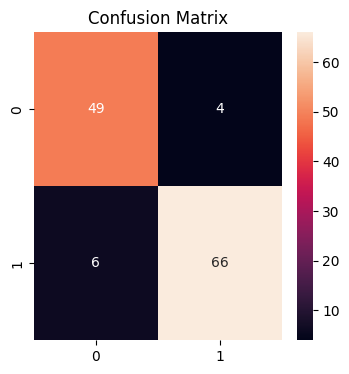

In [19]:
plt.figure(figsize=(4, 4))
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()